# 08 - EfficientNetB0 XAI-Corrected Experiment

This experiment is driven by the XAI audit from `07_xai_gradcam.ipynb`.

Hypotheses from XAI:

- The model may use texture/color shortcuts rather than decay evidence.
- Some predictions may depend on background or image context.
- Some high-confidence errors suggest deployment risk.

Targeted fix:

- stronger translation/zoom/rotation to reduce background dependence
- brightness/contrast/noise augmentation to reduce color/texture shortcuts
- mild targeted oversampling, no class weights
- fine-tune top EfficientNetB0 layers at low learning rate

This notebook does not overwrite `models/best_model.keras`. It saves a new candidate model under `models/experiments/`.


## 1. Project setup


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system


## 2. Imports and configuration


In [2]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    CLASS_NAMES_PATH,
    CM_DIR,
    FIGURES_DIR,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_CLASSES,
    RANDOM_SEED,
    GROUPED_SPLITS_DIR,
)

# Use grouped source-image splits to avoid offline-augmentation leakage.
SPLITS_DIR = GROUPED_SPLITS_DIR
from src.data.augmentations import build_xai_corrected_augmentation
from src.data.dataloaders import make_dataset_from_dataframe
from src.data.prepare_dataset import targeted_oversample_dataframe
from src.models.efficientnetb0_model import build_efficientnetb0_model, unfreeze_efficientnetb0_top
from src.train.evaluate import evaluate_model
from src.train.train import compile_model, train_model

tf.keras.utils.set_random_seed(RANDOM_SEED)

EXPERIMENT_NAME = "efficientnetb0_xai_corrected"
TARGET_MIN_COUNT = 500
PRETRAINED_WEIGHTS = "imagenet"

HEAD_EPOCHS = 8
HEAD_LEARNING_RATE = 1e-3
FINE_TUNE_EPOCHS = 4
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_LAYERS = 40

EXPERIMENT_MODELS_DIR = MODELS_DIR / "experiments"
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment:", EXPERIMENT_NAME)
print("Input size:", IMAGE_SIZE)


I0000 00:00:1777569804.417613   31737 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777569804.475929   31737 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777569830.924867   31737 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: efficientnetb0_xai_corrected
Input size: (224, 224)


## 3. Load splits and class names


In [3]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"

for path in [train_csv, val_csv, test_csv, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}. Run 01_eda.ipynb first.")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8-sig") as f:
    class_names = json.load(f)

class_to_index = {name: idx for idx, name in enumerate(class_names)}

for split_df in [train_df, val_df, test_df]:
    if "class_index" not in split_df.columns:
        split_df["class_index"] = split_df["class_name"].map(class_to_index)

print("Original train/val/test:", len(train_df), len(val_df), len(test_df))
print("Classes:", len(class_names))
assert len(class_names) == NUM_CLASSES


Original train/val/test: 19674 4788 4815
Classes: 28


## 4. Mild targeted oversampling

Only training rows are oversampled. Validation and test remain untouched.


In [4]:
original_counts = train_df["class_name"].value_counts().reindex(class_names)
train_oversampled_df = targeted_oversample_dataframe(
    train_df,
    target_min_count=TARGET_MIN_COUNT,
    class_column="class_name",
    random_state=RANDOM_SEED,
)

oversampled_counts = train_oversampled_df["class_name"].value_counts().reindex(class_names)
oversampling_summary = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": original_counts.values,
    "oversampled_train_count": oversampled_counts.values,
})
oversampling_summary["added_rows"] = oversampling_summary["oversampled_train_count"] - oversampling_summary["original_train_count"]
oversampling_summary["oversampled_ratio"] = (oversampling_summary["oversampled_train_count"] / oversampling_summary["original_train_count"]).round(2)

display(oversampling_summary.sort_values("added_rows", ascending=False))
print("Original train rows:", len(train_df))
print("Oversampled train rows:", len(train_oversampled_df))


,class_name,original_train_count,oversampled_train_count,added_rows,oversampled_ratio
21,Pomegranate__Rotten,131,500,369,3.82
14,Jujube__Healthy,132,500,368,3.79
11,Grape__Rotten,134,500,366,3.73
15,Jujube__Rotten,134,500,366,3.73
12,Guava__Healthy,134,500,366,3.73
10,Grape__Healthy,135,500,365,3.70
13,Guava__Rotten,135,500,365,3.70
20,Pomegranate__Healthy,137,500,363,3.65
7,Carrot__Rotten,390,500,110,1.28
5,Bellpepper__Rotten,390,500,110,1.28


Original train rows: 19674
Oversampled train rows: 23590


## 5. Build datasets


In [5]:
train_ds = make_dataset_from_dataframe(train_oversampled_df, class_to_index, training=True)
val_ds = make_dataset_from_dataframe(val_df, class_to_index, training=False)
test_ds = make_dataset_from_dataframe(test_df, class_to_index, training=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)


I0000 00:00:1777569858.008685   31737 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch: (32, 224, 224, 3)
Label batch: (32,)


## 6. Build XAI-corrected EfficientNetB0


In [6]:
augmentation = build_xai_corrected_augmentation()
model = build_efficientnetb0_model(
    num_classes=NUM_CLASSES,
    augmentation=augmentation,
    dropout_rate=0.35,
    train_base=False,
    weights=PRETRAINED_WEIGHTS,
)
model = compile_model(model, learning_rate=HEAD_LEARNING_RATE)
model.summary()


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xai_corrected_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0_rescale_to_255   │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 28)             │        35,868 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,085,439 (15.58 MB)

 Trainable params: 35,868 (140.11 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 7. Train classifier head


In [7]:
head_checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_head_best.keras"

head_history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=HEAD_EPOCHS,
    checkpoint_path=head_checkpoint_path,
)


Epoch 1/8


I0000 00:00:1777569878.305907   32439 cuda_dnn.cc:461] Loaded cuDNN version 92100


373/738 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.6142 - loss: 1.4844

W0000 00:00:1777569921.085078   32587 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


675/738 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.7041 - loss: 1.1478

...

738/738 ━━━━━━━━━━━━━━━━━━━━ 123s 163ms/step - accuracy: 0.9642 - loss: 0.1192 - val_accuracy: 0.9586 - val_loss: 0.1597 - learning_rate: 0.0010
Epoch 8/8
376/738 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9669 - loss: 0.1080

W0000 00:00:1777570697.070984   36151 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


633/738 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9668 - loss: 0.1083

W0000 00:00:1777570725.873741   36152 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


738/738 ━━━━━━━━━━━━━━━━━━━━ 108s 136ms/step - accuracy: 0.9671 - loss: 0.1068 - val_accuracy: 0.9572 - val_loss: 0.1554 - learning_rate: 0.0010


## 8. Fine-tune top EfficientNetB0 layers

BatchNorm layers remain frozen in `unfreeze_efficientnetb0_top()` to reduce instability.


In [8]:
fine_tune_checkpoint_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_finetuned_best.keras"

model = unfreeze_efficientnetb0_top(model, trainable_layers=FINE_TUNE_LAYERS)
model = compile_model(model, learning_rate=FINE_TUNE_LEARNING_RATE)

fine_tune_history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=FINE_TUNE_EPOCHS,
    checkpoint_path=fine_tune_checkpoint_path,
)


Epoch 1/4


E0000 00:00:1777570771.258454   31737 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_transfer_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


383/738 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.9719 - loss: 0.0931

W0000 00:00:1777570816.946914   36613 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


673/738 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.9716 - loss: 0.0921

...

738/738 ━━━━━━━━━━━━━━━━━━━━ 90s 119ms/step - accuracy: 0.9790 - loss: 0.0681 - val_accuracy: 0.9664 - val_loss: 0.1264 - learning_rate: 1.0000e-05
Epoch 4/4
359/738 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.9785 - loss: 0.0671

W0000 00:00:1777571079.088552   37859 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


642/738 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.9785 - loss: 0.0676

W0000 00:00:1777571110.324800   37854 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


738/738 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.9798 - loss: 0.0644 - val_accuracy: 0.9668 - val_loss: 0.1209 - learning_rate: 1.0000e-05


## 9. Training curves


,accuracy,loss,val_accuracy,val_loss,learning_rate,stage
0,0.846333,0.602915,0.913325,0.316701,0.00100,head
1,0.935100,0.233288,0.936299,0.243625,0.00100,head
2,0.947944,0.179964,0.945906,0.206840,0.00100,head
3,0.955702,0.152444,0.947577,0.193591,0.00100,head
4,0.960365,0.134998,0.951337,0.180599,0.00100,head
5,0.962569,0.124864,0.957811,0.166560,0.00100,head
6,0.964222,0.119169,0.958647,0.159675,0.00100,head
7,0.967147,0.106828,0.957185,0.155424,0.00100,head
8,0.972573,0.087089,0.963033,0.138530,0.00001,fine_tune
9,0.975964,0.076590,0.963450,0.132381,0.00001,fine_tune


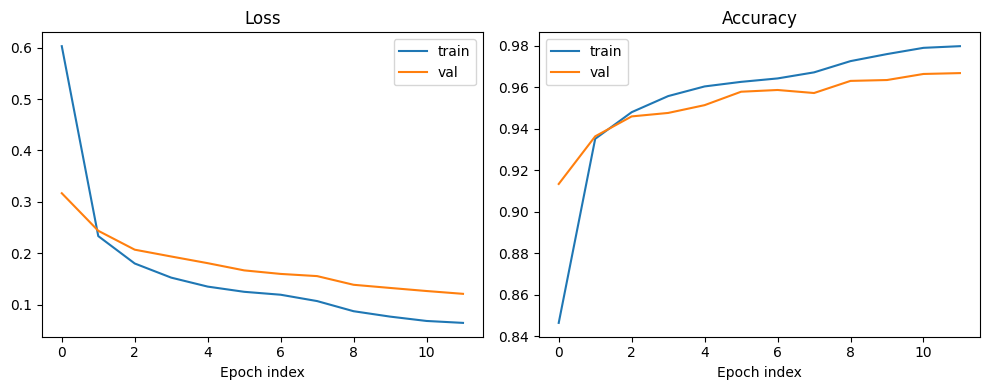

In [9]:
head_history_df = pd.DataFrame(head_history.history)
head_history_df["stage"] = "head"
fine_tune_history_df = pd.DataFrame(fine_tune_history.history)
fine_tune_history_df["stage"] = "fine_tune"
history_df = pd.concat([head_history_df, fine_tune_history_df], ignore_index=True)
display(history_df)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df.index, history_df["loss"], label="train")
plt.plot(history_df.index, history_df["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch index")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df.index, history_df["accuracy"], label="train")
plt.plot(history_df.index, history_df["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch index")
plt.legend()

plt.tight_layout()
curves_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()


## 10. Evaluate on test set


In [10]:
results = evaluate_model(model, test_ds, class_names)
report = results["classification_report"]
cm = results["confusion_matrix"]

report_df = pd.DataFrame(report).transpose()
display(report_df)

accuracy = float(report["accuracy"])
macro_f1 = float(report["macro avg"]["f1-score"])
weighted_f1 = float(report["weighted avg"]["f1-score"])

print("Test accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))


W0000 00:00:1777571150.231825   38277 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


,precision,recall,f1-score,support
Apple__Healthy,0.970297,0.994924,0.982456,394.000000
Apple__Rotten,0.974468,0.944330,0.959162,485.000000
Banana__Healthy,0.986254,1.000000,0.993080,287.000000
Banana__Rotten,1.000000,0.987578,0.993750,483.000000
Bellpepper__Healthy,0.942857,0.970588,0.956522,102.000000
Bellpepper__Rotten,0.909091,0.800000,0.851064,100.000000
Carrot__Healthy,0.887931,1.000000,0.940639,103.000000
Carrot__Rotten,0.987013,0.800000,0.883721,95.000000
Cucumber__Healthy,0.934579,0.980392,0.956938,102.000000
Cucumber__Rotten,0.967391,0.927083,0.946809,96.000000


Test accuracy: 0.9641
Macro F1: 0.9523
Weighted F1: 0.9639


## 11. High-confidence error audit

This is a deployment-risk metric, not just a training metric.


In [11]:
audit_df = test_df.copy().reset_index(drop=True)
audit_df["y_true"] = results["y_true"]
audit_df["y_pred"] = results["y_pred"]
audit_df["predicted_class"] = [class_names[idx] for idx in audit_df["y_pred"]]
audit_df["correct"] = audit_df["class_name"] == audit_df["predicted_class"]

probabilities = model.predict(test_ds, verbose=1)
audit_df["confidence"] = np.max(probabilities, axis=1)
audit_df["high_confidence_error"] = (~audit_df["correct"]) & (audit_df["confidence"] >= 0.95)

print("Errors:", int((~audit_df["correct"]).sum()))
print("High-confidence errors:", int(audit_df["high_confidence_error"].sum()))
display(audit_df[audit_df["high_confidence_error"]][["class_name", "predicted_class", "confidence", "image_path"]].head(20))


 74/151 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step

W0000 00:00:1777571165.437599   45032 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


151/151 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step
Errors: 173
High-confidence errors: 17


,class_name,predicted_class,confidence,image_path
693,Pomegranate__Rotten,Pomegranate__Healthy,0.952040,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
839,Carrot__Rotten,Carrot__Healthy,0.990774,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
1252,Tomato__Rotten,Bellpepper__Rotten,0.956008,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
1819,Bellpepper__Rotten,Bellpepper__Healthy,0.997438,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
1888,Potato__Rotten,Potato__Healthy,0.952945,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
2089,Apple__Rotten,Potato__Rotten,0.977881,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
2105,Bellpepper__Rotten,Tomato__Rotten,0.990426,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
2140,Tomato__Healthy,Orange__Healthy,0.970864,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
2525,Bellpepper__Rotten,Tomato__Rotten,0.957813,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...
2995,Potato__Rotten,Potato__Healthy,0.998301,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...


## 12. Confusion matrix


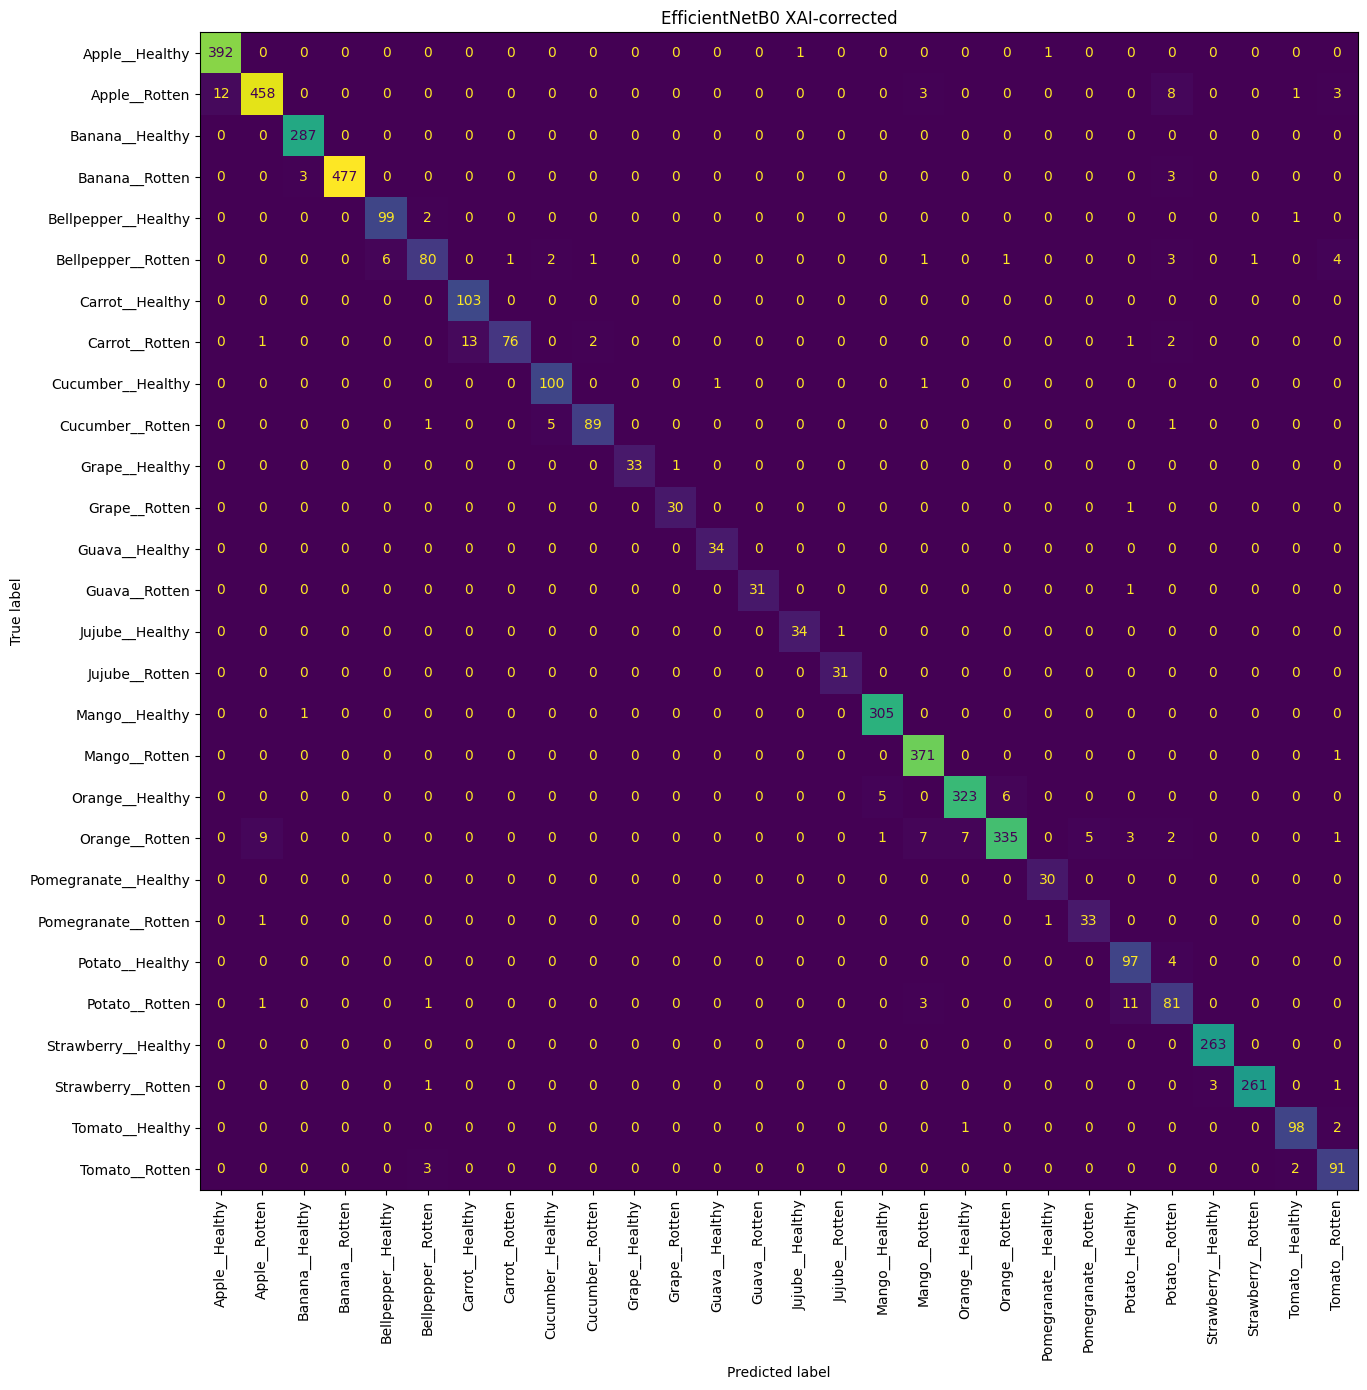

In [12]:
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("EfficientNetB0 XAI-corrected")
plt.tight_layout()
cm_path = CM_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


## 13. Save artifacts


In [13]:
model_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}.keras"
metadata_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_metadata.json"
report_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_classification_report.csv"
history_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_history.csv"
audit_path = FIGURES_DIR / f"{EXPERIMENT_NAME}_audit.csv"
oversampling_summary_path = EXPERIMENT_MODELS_DIR / f"{EXPERIMENT_NAME}_oversampling_summary.csv"

model.save(model_path)
report_df.to_csv(report_path)
history_df.to_csv(history_path, index=False)
audit_df.to_csv(audit_path, index=False)
oversampling_summary.to_csv(oversampling_summary_path, index=False)

metadata = {
    "model_name": EXPERIMENT_NAME,
    "base_model_family": "EfficientNetB0",
    "experiment_type": "xai_guided_corrected_training",
    "hypotheses": ["background_bias", "texture_bias", "class_confusion", "unstable_attention"],
    "targeted_fixes": ["stronger_geometric_augmentation", "brightness_contrast_jitter", "gaussian_noise", "deeper_fine_tuning"],
    "num_classes": NUM_CLASSES,
    "image_size": list(IMAGE_SIZE),
    "head_epochs_requested": HEAD_EPOCHS,
    "head_learning_rate": HEAD_LEARNING_RATE,
    "fine_tune_epochs_requested": FINE_TUNE_EPOCHS,
    "fine_tune_learning_rate": FINE_TUNE_LEARNING_RATE,
    "fine_tune_layers": FINE_TUNE_LAYERS,
    "augmentation": "xai_corrected_augmentation",
    "class_weighting": None,
    "oversampling": {
        "enabled": True,
        "strategy": "targeted_min_count_with_replacement",
        "target_min_count": TARGET_MIN_COUNT,
        "original_train_rows": int(len(train_df)),
        "oversampled_train_rows": int(len(train_oversampled_df)),
    },
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "metrics": {
        "test_accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "errors": int((~audit_df["correct"]).sum()),
        "high_confidence_errors": int(audit_df["high_confidence_error"].sum()),
    },
    "artifacts": {
        "model": str(model_path),
        "head_checkpoint": str(head_checkpoint_path),
        "fine_tune_checkpoint": str(fine_tune_checkpoint_path),
        "classification_report": str(report_path),
        "history": str(history_path),
        "audit": str(audit_path),
        "confusion_matrix": str(cm_path),
        "training_curves": str(curves_path),
    },
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)
print("Did not overwrite models/best_model.keras")


Saved model: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/efficientnetb0_xai_corrected.keras
Saved metadata: /mnt/d/UWE/3rd Year/2nd semester/advanced_ai/ai_system/models/experiments/efficientnetb0_xai_corrected_metadata.json
Did not overwrite models/best_model.keras


## 14. Decision rule

This corrected model is better only if it improves or preserves macro F1 while reducing high-confidence errors and producing more plausible XAI attention in notebook 09.
